In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
#for item in cl.get_platforms():
#    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

C:\Anaconda3\lib\site-packages\pytools\persistent_dict.py:59: UserWarning: pytools.persistent_dict: unable to import 'siphash24.siphash13', falling back to hashlib.sha256
  warn("pytools.persistent_dict: unable to import 'siphash24.siphash13', "


No cuda device found. Check your pycuda installation.
('ocl', 0, 0, <pyopencl.Platform 'Intel(R) OpenCL Graphics' at 0x1daac2f8dc0>, <pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x1daaf250810>, <reikna.cluda.ocl.Thread object at 0x000001DAAEB26F70>, 64)
('ocl', 1, 0, <pyopencl.Platform 'Intel(R) OpenCL' at 0x1daaf22a8d0>, <pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x1daacc95780>, <reikna.cluda.ocl.Thread object at 0x000001DAAEB39D90>, 1)
('ocl', 2, 0, <pyopencl.Platform 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x1daaf22ced0>, <pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x1daacc93e80>, <reikna.cluda.ocl.Thread object at 0x000001DAAEB39760>, 64)


# hpSpiral3d Recon

We first build the k-mesh as in the previous section

And the NuFFT result seems resonable.

Create auxiliary function that wraps the whole processing scripts:

In [2]:
def parse_spiral_stack_data(target_exp, does_recon_k=False, does_recon_img=False):
    FID = np.array([])
    traj_Kxy=np.array([])
    traj_K3d=np.array([])
    recon=np.array([])
    
    
    FID = target_exp.dataset['DATA']['rawdata'][0]
    NR = target_exp.dataset['PARAM']['method'][0]['PVM_NRepetitions']
    FID = np.reshape(FID, [NR, -1])
    
    if does_recon_k:
    
        intvl = int(1e3*target_exp.dataset['PARAM']['method'][0]['PVM_SpiralAcqDwellTime']/target_exp.dataset['PARAM']['method'][0]['PVM_SpiralGradDwellTime'])

        shift_cos = (target_exp.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
        shift_sin = (target_exp.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
        shift_angle = np.angle(shift_cos+1j*shift_sin)

        nbr_pts_intvl_ro = target_exp.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']


        traj_cal_x = np.cumsum(target_exp.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])[::intvl]
        traj_cal_y = np.cumsum(target_exp.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])[::intvl]
        traj_cal_seg = traj_cal_x + 1j*traj_cal_y
        traj_cal_seg = traj_cal_seg[:nbr_pts_intvl_ro]

        traj_cal = []
        for angle in shift_angle:
            traj_cal.append(traj_cal_seg * np.exp( (-np.pi/2 - angle)*1j))

        traj_cal = np.asarray(traj_cal).flatten()
        traj_Kxy = traj_cal / np.max(np.abs(traj_cal))

        traj_Kz = target_exp.dataset['PARAM']['method'][0]['PVM_EncSteps2']
        traj_Kz = traj_Kz / np.max(traj_Kz)

        traj_K3d = []
        for kz in traj_Kz:
            for kxy in traj_Kxy:
                traj_K3d.append([kxy.real, kxy.imag, kz])
        traj_K3d = np.asarray(traj_K3d)

        if does_recon_img:
            img_shape = [int(x) for x in target_exp.dataset['PARAM']['method'][0]['PVM_Matrix']]
            Nd = tuple(img_shape)  # image size
            Kd = tuple([8*x for x in img_shape])  # k-space size
            Jd = (6, 6, 6)  # interpolation size

            # this line takes the CPU approach, which is at least 4 times slower with all 16 cores 100% occupied
            spiralStackObj = pynufft.NUFFT() 
            # this line takes the GPU approach, which requires the pycuda package finds a GPU
            #spiralStackObj = pynufft.NUFFT(pynufft.helper.device_list()[0])
            spiralStackObj.plan(traj_K3d*np.pi, Nd, Kd, Jd)

            time1 = time.time()
            recon = [ spiralStackObj.solve(FID[2], solver='cg', maxiter=500) for fid in FID]
            time2 = time.time()
            print(time2-time1)
    
    return FID, traj_Kxy, traj_K3d, recon
    



17.701181888580322


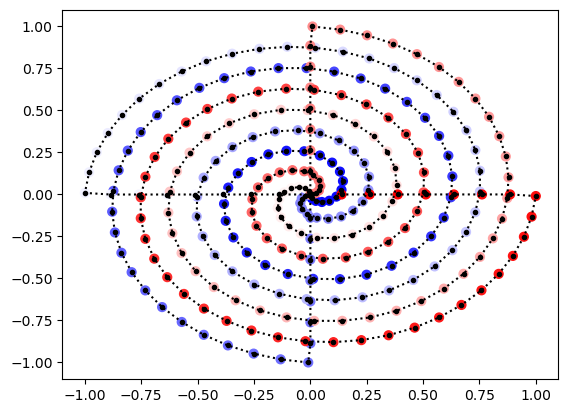

C:\Anaconda3\lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


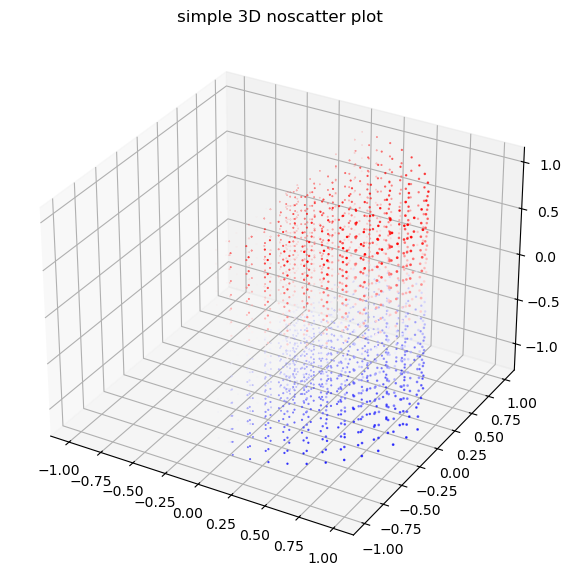

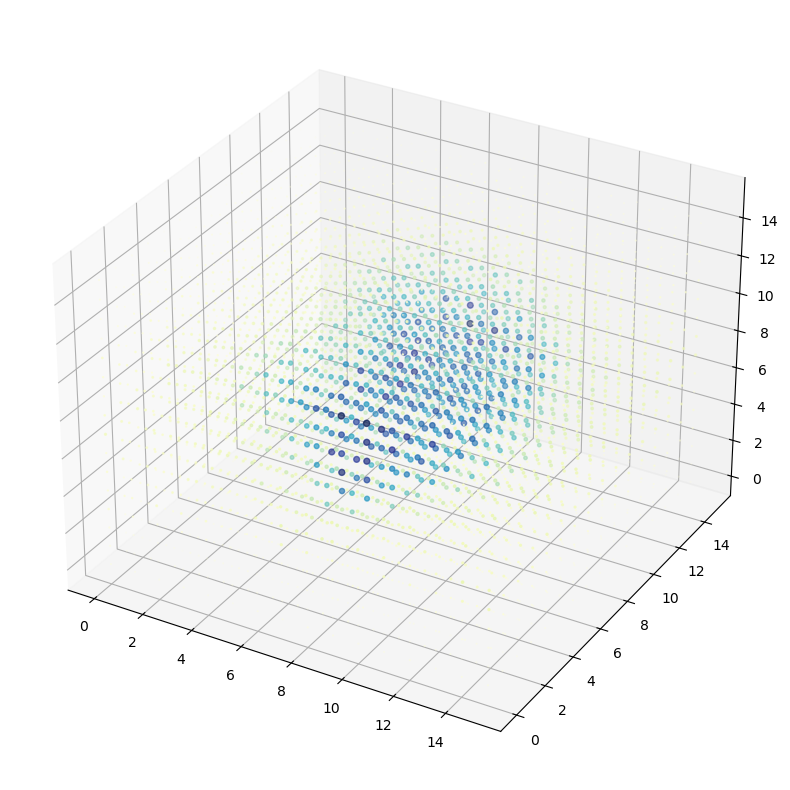

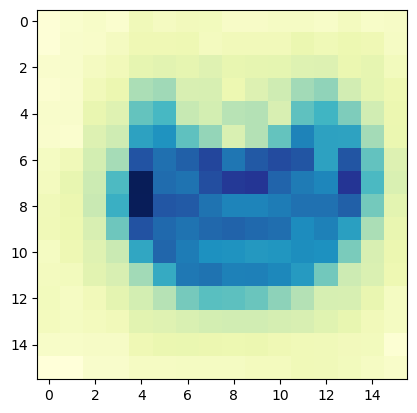

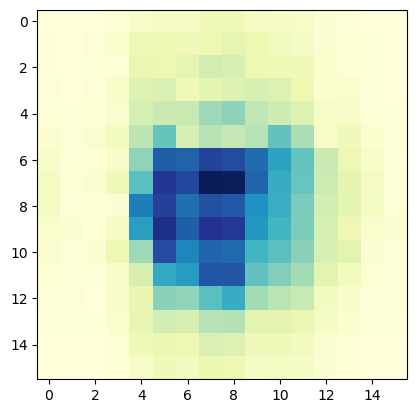

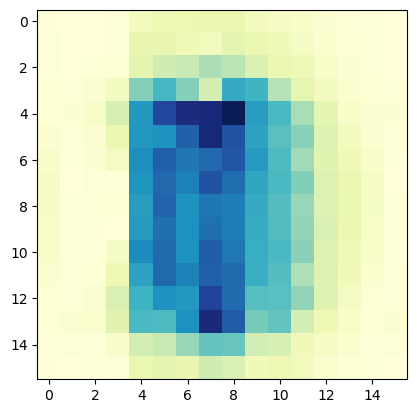

In [3]:
raw_path = "C:/Users/Xiao JI/OneDrive - University of California, San Francisco/Documents/Projects/HP-bSSFP/20240731-FreqSweep/proton-pm-2kHz/7"

SpiralStack3d = BrukerPV360Exp(raw_path, is_verbose=False)

FID, traj_Kxy, traj_K3d, recon = parse_spiral_stack_data(SpiralStack3d, does_recon_k=True, does_recon_img=True)

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_Kxy))), s=40, cmap='bwr')
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
ax.scatter3D(traj_K3d[:,0], traj_K3d[:,1], traj_K3d[:,2], c=traj_K3d[:,2], s = traj_K3d[:,0], cmap='bwr')
plt.title("simple 3D noscatter plot") 
# show plot
plt.show()


from itertools import product
from matplotlib import pyplot as plt
N = 16
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
space = np.array([*product(range(N), range(N), range(N))]) # all possible triplets of numbers from 0 to N-1
volume = normalize_array(np.abs(recon[0]))
ax.scatter(space[:,0], space[:,1], space[:,2], c=volume, s=volume*20, cmap='YlGnBu')

plt.figure()
plt.imshow(np.abs(recon[0])[:,:,8], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon[0])[:,8,:], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon[0])[8,:,:], cmap=cm.YlGnBu)
plt.show()

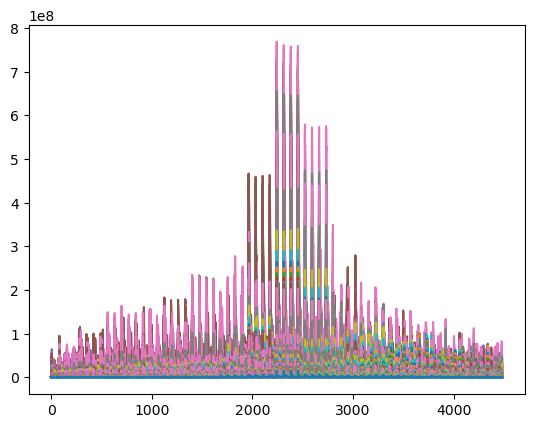

In [4]:
path_root = 'C:/Users/Xiao JI/OneDrive - University of California, San Francisco/Documents/Projects/HP-bSSFP/20240731-FreqSweep/proton-pm-2kHz'
exp_idx_list = np.arange(12,413)
fids = []


for exp_idx in exp_idx_list:
    exp_path = os.path.join(path_root, str(exp_idx))
    SpiralStack3d = BrukerPV360Exp(exp_path, is_verbose=False)
    offset = (SpiralStack3d.dataset['PARAM']['method'][0]['PVM_FrqWorkOffset'])[0]
    FID, _, _, _ = parse_spiral_stack_data(SpiralStack3d, does_recon_k=False, does_recon_img=False)
    fids.append((offset, FID))
    plt.plot(np.abs(FID[0]))

plt.show()


In [5]:
fid_norms = []

for offset, fid in fids:
    
    tmp = np.asarray([np.sum(np.abs(stack)) for stack in fid])
    tmp = np.concatenate((np.asarray([offset]), tmp))
    fid_norms.append(tmp)
    
fid_norms = np.asarray(fid_norms)



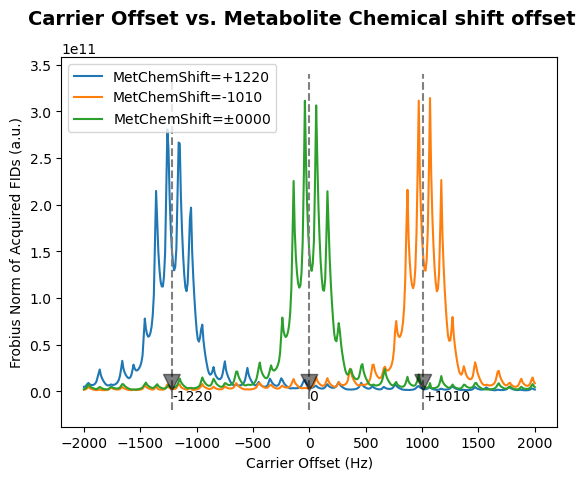

In [6]:

plt.figure()
plt.plot(fid_norms[:,0], (fid_norms[:,1]), label="MetChemShift=+1220")
plt.plot(fid_norms[:,0], (fid_norms[:,2]), label="MetChemShift=-1010")
plt.plot(fid_norms[:,0], (fid_norms[:,3]), label="MetChemShift=$\pm$0000")

plt.vlines(x=0, ymin=-2e10, ymax=3.4e11, color="grey", linestyle="dashed")
plt.vlines(x=1010, ymin=-2e10, ymax=3.4e11, color="grey", linestyle="dashed")
plt.vlines(x=-1220, ymin=-2e10, ymax=3.4e11, color="grey", linestyle="dashed")

plt.annotate('0', xy=(0, 0), xytext=(0, -1e10),arrowprops=dict(facecolor='black', shrink=0.05, alpha=.5))
plt.annotate('+1010', xy=(1010, 0), xytext=(1010, -1e10),arrowprops=dict(facecolor='black', shrink=0.05, alpha=.5))
plt.annotate('-1220', xy=(-1220, 0), xytext=(-1220, -1e10),arrowprops=dict(facecolor='black', shrink=0.05, alpha=.5))

plt.suptitle('Carrier Offset vs. Metabolite Chemical shift offset', fontsize=14, fontweight='bold')

plt.xlabel('Carrier Offset (Hz)')
plt.ylabel('Frobius Norm of Acquired FIDs (a.u.)')


plt.legend()
plt.show()

In [7]:
fid_norms[:,2]

array([8.50317510e+09, 1.05858635e+10, 1.47467486e+10, 1.21197085e+10,
       8.68486849e+09, 6.74423810e+09, 5.95072486e+09, 5.82661738e+09,
       6.27599193e+09, 7.02329145e+09, 8.19986916e+09, 9.92472531e+09,
       1.33647180e+10, 1.10799501e+10, 7.87087921e+09, 5.87330276e+09,
       5.06241923e+09, 4.79072047e+09, 4.94140366e+09, 5.33737032e+09,
       6.03422010e+09, 7.06127420e+09, 9.04450945e+09, 8.58758444e+09,
       7.23546960e+09, 6.37751542e+09, 6.46133323e+09, 7.26144789e+09,
       8.93031488e+09, 1.08858797e+10, 1.32141301e+10, 1.63975464e+10,
       2.19204591e+10, 2.09594587e+10, 1.54083208e+10, 1.06890849e+10,
       8.52898915e+09, 7.34831439e+09, 6.70592418e+09, 6.34328044e+09,
       6.21969361e+09, 6.32112265e+09, 6.86205794e+09, 6.94902724e+09,
       6.49051726e+09, 6.61921587e+09, 7.38621639e+09, 8.68199562e+09,
       1.10320703e+10, 1.36709300e+10, 1.67224664e+10, 2.06640302e+10,
       2.65503267e+10, 3.09888754e+10, 2.32502129e+10, 1.62353036e+10,
      